# Introduction to Feature Scaling

Feature Scaling is the process of transforming numerical features so they are on a similar scale.

In real-world datasets, features often have different ranges:
- Age → 18 to 60
- Salary → 10,000 to 1,00,000
- Alcohol → 8 to 14

If we do not scale features, machine learning models may give biased importance to larger-scale features.

# Why Feature Scaling is Important in Machine Learning

Feature scaling is important because:
- Distance-based models (KNN, K-Means) are sensitive to scale
- Gradient-based models (Linear Regression, Logistic Regression) converge faster
- Neural Networks perform better with scaled inputs
- Prevents one feature from dominating others

Models that require scaling:
- KNN
- SVM
- K-Means
- PCA
- Neural Networks

# Loading Dataset for Feature Scaling

We will use a numerical dataset (e.g., Wine Quality dataset)
to demonstrate scaling techniques on real-world features.

In [ ]:
# !pip install scikit-learn

In [2]:
# Import required libraries for preprocessing and scaling
# Load the dataset
# Preview dataset structure
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv("/home/fm-pc-lt-269/Desktop/data_science/notebooks/data/winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
wine_num_df = df.select_dtypes(include=np.number)
wine_num_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Understanding Feature Ranges Before Scaling

Before applying scaling, we must analyze:
- Minimum values
- Maximum values
- Feature ranges
- Distribution spread

In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
df.min()

fixed acidity           4.60000
volatile acidity        0.12000
citric acid             0.00000
residual sugar          0.90000
chlorides               0.01200
free sulfur dioxide     1.00000
total sulfur dioxide    6.00000
density                 0.99007
pH                      2.74000
sulphates               0.33000
alcohol                 8.40000
quality                 3.00000
dtype: float64

In [9]:
df.max()

fixed acidity            15.90000
volatile acidity          1.58000
citric acid               1.00000
residual sugar           15.50000
chlorides                 0.61100
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
density                   1.00369
pH                        4.01000
sulphates                 2.00000
alcohol                  14.90000
quality                   8.00000
dtype: float64

In [ ]:
# Select numerical features from the dataset

# Check summary statistics (min, max, mean, std)

# Compare feature ranges

## Absolute Maximum Scaling

Absolute Maximum Scaling is a feature scaling technique where each value is divided by the maximum absolute value of that feature. This transformation rescales the data so that all values lie within the range of -1 to 1.

### Formula

$$
X_{\text{scaled}} = \frac{X_i}{\max(|X|)}
$$

Where:
- $X_i$ = Original value  
- $\max(|X|)$ = Maximum absolute value in the feature

### Key Characteristics
- Scales feature values between **-1 and 1**
- Preserves the shape of the original distribution
- Simple and computationally efficient

### Limitation
- Highly sensitive to outliers  
  - A single extreme value can increase the maximum absolute value
  - This causes most other values to shrink towards zero
  - Makes it less suitable for noisy or outlier-heavy datasets

In [ ]:
# Select Numeric Features anf Perform Absolute maximum scaling
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

max_abs_scaled = pd.DataFrame(
    scaler.fit_transform(wine_num_df),
    columns = wine_num_df.columns
)
max_abs_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.465409,0.443038,0.00,0.122581,0.124386,0.152778,0.117647,0.994132,0.875312,0.280,0.630872,0.625
1,0.490566,0.556962,0.00,0.167742,0.160393,0.347222,0.231834,0.993135,0.798005,0.340,0.657718,0.625
2,0.490566,0.481013,0.04,0.148387,0.150573,0.208333,0.186851,0.993335,0.812968,0.325,0.657718,0.625
3,0.704403,0.177215,0.56,0.122581,0.122750,0.236111,0.207612,0.994331,0.788030,0.290,0.657718,0.750
4,0.465409,0.443038,0.00,0.122581,0.124386,0.152778,0.117647,0.994132,0.875312,0.280,0.630872,0.625


In [13]:
wine_num_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Min-Max Scaling

Min-Max Scaling is a feature scaling technique that transforms values by subtracting the minimum value and dividing by the range (maximum minus minimum).  
This method maps feature values to a fixed range, commonly between 0 and 1, while preserving the original shape of the distribution.

### Formula

$$
X_{\text{scaled}} = \frac{X_i - X_{\min}}{X_{\max} - X_{\min}}
$$

Where:
- $X_i$ = Original value  
- $X_{\min}$ = Minimum value of the feature  
- $X_{\max}$ = Maximum value of the feature  

### Key Characteristics
- Scales features to a specific range (usually 0 to 1)
- Preserves the original distribution shape
- Easy to interpret and implement

### Limitation
- Sensitive to outliers  
  - Extreme values affect $X_{\min}$ and $X_{\max}$
  - Can compress the majority of data into a very small range

## When to Use Min Max Normalization


Normalization is preferred when:
- Data does not follow normal distribution
- Neural Networks are used
- Distance-based algorithms (KNN, K-Means) are applied
- Features have different ranges

In [17]:
# Import MinMaxScaler from sklearn.preprocessing
# Initialize MinMaxScaler
# Fit scaler on numerical features
# Transform the dataset using normalization
# Create a scaled dataframe

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

min_max_scale = pd.DataFrame(
    scaler.fit_transform(wine_num_df),
    columns=wine_num_df.columns
)
min_max_scale.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385,0.4
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385,0.4
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385,0.6
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4


In [19]:
min_max_scale.min()

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

In [20]:
min_max_scale.max()

fixed acidity           1.0
volatile acidity        1.0
citric acid             1.0
residual sugar          1.0
chlorides               1.0
free sulfur dioxide     1.0
total sulfur dioxide    1.0
density                 1.0
pH                      1.0
sulphates               1.0
alcohol                 1.0
quality                 1.0
dtype: float64

# Visual Comparison: Before vs After Normalization

Visualization helps understand how scaling compresses feature ranges.

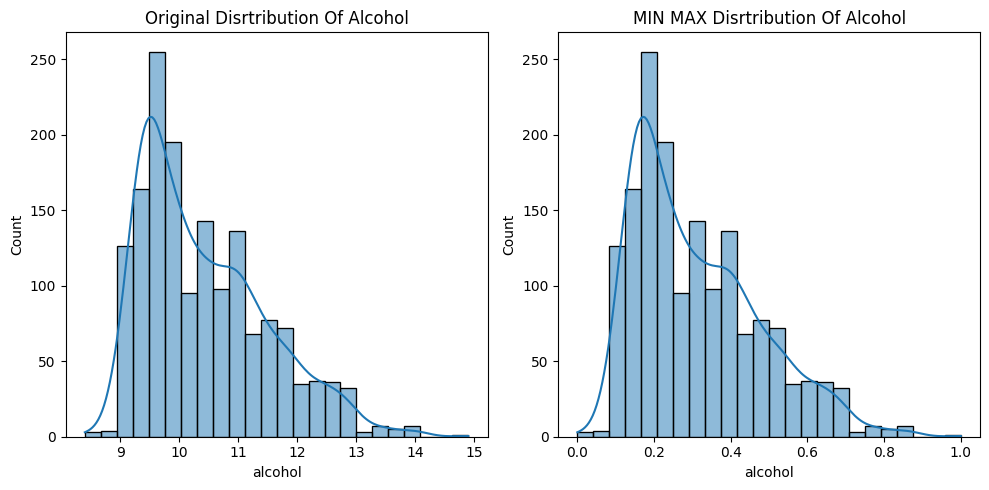

In [23]:
# Plot histogram of original feature
# Plot histogram of normalized feature
# Compare distribution shapes

fig, axes  = plt.subplots(1,2, figsize =(10,5))

sns.histplot(wine_num_df["alcohol"], kde = True,  ax = axes[0])
axes[0].set_title("Original Disrtribution Of Alcohol")

sns.histplot(min_max_scale["alcohol"], kde = True,  ax = axes[1])
axes[1].set_title("MIN MAX Disrtribution Of Alcohol")

plt.tight_layout()
plt.show()

## Normalization (Vector Normalization)

Normalization (Vector Normalization) scales each data sample (row) so that its vector length (Euclidean norm) becomes 1.  
This method emphasizes the **direction** of the data rather than its magnitude, making it especially useful in algorithms that rely on distance or cosine similarity, such as text classification and clustering.

### Formula

$$
X_{\text{scaled}} = \frac{X_i}{\|X\|}
$$

Where:
- $X_i$ = Each individual value in the vector  
- $\|X\|$ = Euclidean norm (length) of the vector $X$  
- $\|X\| = \sqrt{x_1^2 + x_2^2 + \cdots + x_n^2}$

### Key Characteristics
- Normalizes each sample (row) to unit length (norm = 1)
- Preserves the direction of the data points
- Reduces the impact of magnitude differences between samples

### When to Use
- Cosine similarity-based models
- Text vectorization (TF-IDF, embeddings)
- Clustering algorithms (e.g., K-Means with cosine distance)

In [24]:
# Perform Vector Normalization
from sklearn.preprocessing import Normalizer

scaler = Normalizer()

vector_norm_scaled = pd.DataFrame(
    scaler.fit_transform(wine_num_df),
    columns=wine_num_df.columns
)
vector_norm_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.193478,0.018302,0.000000,0.049677,0.001987,0.287602,0.888952,0.026088,0.091771,0.014642,0.245769,0.130728
1,0.106989,0.012071,0.000000,0.035663,0.001344,0.342913,0.919006,0.013673,0.043893,0.009327,0.134422,0.068583
2,0.134949,0.013149,0.000692,0.039793,0.001592,0.259517,0.934261,0.017249,0.056402,0.011246,0.169551,0.086506
3,0.173611,0.004340,0.008681,0.029452,0.001163,0.263517,0.930059,0.015470,0.048983,0.008991,0.151910,0.093006
4,0.193478,0.018302,0.000000,0.049677,0.001987,0.287602,0.888952,0.026088,0.091771,0.014642,0.245769,0.130728


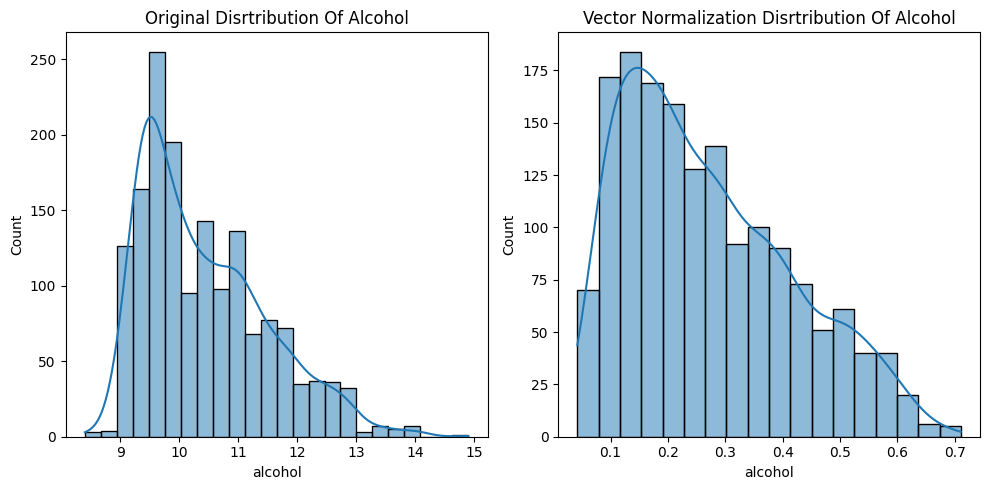

In [25]:
fig, axes  = plt.subplots(1,2, figsize =(10,5))

sns.histplot(wine_num_df["alcohol"], kde = True,  ax = axes[0])
axes[0].set_title("Original Disrtribution Of Alcohol")

sns.histplot(vector_norm_scaled["alcohol"], kde = True,  ax = axes[1])
axes[1].set_title("Vector Normalization Disrtribution Of Alcohol")

plt.tight_layout()
plt.show()

## Standardization (Z-Score Scaling)

Standardization is a feature scaling technique that centers the data by subtracting the mean and scales it by dividing by the standard deviation.  
This transformation results in features with a mean of 0 and a standard deviation of 1 (unit variance).

It is especially useful for models that assume normally distributed data, such as linear regression, logistic regression, and neural networks, as it improves convergence speed and numerical stability.

### Formula

$$
X_{\text{scaled}} = \frac{X_i - \mu}{\sigma}
$$

Where:
- $X_i$ = Original value  
- $\mu$ = Mean of the feature  
- $\sigma$ = Standard deviation of the feature  

### Key Characteristics
- Produces features with mean ≈ 0
- Produces features with variance ≈ 1
- Maintains the shape of the original distribution


## When to Use Standardization

Standardization is preferred when:
- Data follows normal distribution
- Algorithms assume Gaussian distribution
- PCA and Linear Models are used
- Outliers are present (more robust than normalization)  
- Distance-based algorithms (KNN, SVM)  
- Gradient-based models (Linear Regression, Logistic Regression, Neural Networks)

In [32]:
# Import StandardScaler from sklearn.preprocessing
# Initialize StandardScaler
# Fit scaler on numerical features
# Transform dataset using standardization
# Create standardized dataframe

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

stand_scale = pd.DataFrame(
    scaler.fit_transform(wine_num_df),
    columns=wine_num_df.columns
)
stand_scale.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.53,0.96,-1.39,-0.45,-0.24,-0.47,-0.38,0.56,1.29,-0.58,-0.96,-0.79
1,-0.30,1.97,-1.39,0.04,0.22,0.87,0.62,0.03,-0.72,0.13,-0.58,-0.79
2,-0.30,1.30,-1.19,-0.17,0.10,-0.08,0.23,0.13,-0.33,-0.05,-0.58,-0.79
3,1.65,-1.38,1.48,-0.45,-0.26,0.11,0.41,0.66,-0.98,-0.46,-0.58,0.45
4,-0.53,0.96,-1.39,-0.45,-0.24,-0.47,-0.38,0.56,1.29,-0.58,-0.96,-0.79


In [33]:
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [34]:
stand_scale.mean()

fixed acidity           0.00
volatile acidity        0.00
citric acid            -0.00
residual sugar         -0.00
chlorides               0.00
free sulfur dioxide    -0.00
total sulfur dioxide    0.00
density                -0.00
pH                      0.00
sulphates               0.00
alcohol                 0.00
quality                 0.00
dtype: float64

In [35]:
stand_scale.std()

fixed acidity          1.00
volatile acidity       1.00
citric acid            1.00
residual sugar         1.00
chlorides              1.00
free sulfur dioxide    1.00
total sulfur dioxide   1.00
density                1.00
pH                     1.00
sulphates              1.00
alcohol                1.00
quality                1.00
dtype: float64

# Comparing Normalization vs Standardization

Key Differences:

Normalization:
- Scales data to [0, 1]
- Sensitive to outliers
- Best for neural networks & distance models

Standardization:
- Mean = 0, Std = 1
- Less affected by outliers
- Best for linear models and PCA

In [37]:
# Compare mean and standard deviation before scaling
print("Mean of Alcoholl in original data", wine_num_df['alcohol'].mean())
print("Mean of Alcoholl in Standard Scaled data", stand_scale['alcohol'].mean())
# Compare mean and standard deviation after standardization

# Analyze scaling impact numerically

Mean of Alcoholl in original data 10.422983114446529
Mean of Alcoholl in Standard Scaled data 1.0664806540489309e-16


In [38]:
wine_num_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5


## Robust Scaling

Robust Scaling is a feature scaling technique that uses the **median** and **Interquartile Range (IQR)** instead of the mean and standard deviation.  
This makes the transformation highly robust to outliers and suitable for skewed or noisy datasets.

### Formula

$$
X_{\text{scaled}} = \frac{X_i - X_{\text{median}}}{\text{IQR}}
$$

Where:
- $X_i$ = Original value  
- $X_{\text{median}}$ = Median of the feature  
- $\text{IQR} = Q_3 - Q_1$ (Interquartile Range)  

### Key Characteristics
- Centers data using the median
- Scales using the IQR (middle 50% of the data)
- Less sensitive to extreme values and outliers

### Advantages
- Reduces the influence of outliers
- Works well for skewed distributions
- More stable than Standardization when data contains noise or extreme values

## When to Use Robust Scaling

- Dataset has many **outliers**
- Features are **heavily skewed** (positive or negative skew)
- Presence of **extreme values** that distort mean and standard deviation
- Real-world data such as:
  - Financial data (income, expenses)
  - Sensor readings
  - Sales and revenue data

In [39]:
# Perform Robust Scaling
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

robust_scaled = pd.DataFrame(
    scaler.fit_transform(wine_num_df),
    columns=wine_num_df.columns
)
robust_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.24,0.72,-0.79,-0.43,-0.15,-0.21,-0.10,0.47,1.05,-0.33,-0.50,-1.00
1,-0.05,1.44,-0.79,0.57,0.95,0.79,0.72,0.02,-0.58,0.33,-0.25,-1.00
2,-0.05,0.96,-0.67,0.14,0.65,0.07,0.40,0.11,-0.26,0.17,-0.25,-1.00
3,1.57,-0.96,0.91,-0.43,-0.20,0.21,0.55,0.56,-0.79,-0.22,-0.25,0.00
4,-0.24,0.72,-0.79,-0.43,-0.15,-0.21,-0.10,0.47,1.05,-0.33,-0.50,-1.00


In [40]:
robust_scaled.min()

fixed acidity          -1.57
volatile acidity       -1.60
citric acid            -0.79
residual sugar         -1.86
chlorides              -3.35
free sulfur dioxide    -0.93
total sulfur dioxide   -0.80
density                -2.99
pH                     -3.00
sulphates              -1.61
alcohol                -1.12
quality                -3.00
dtype: float64

## Comparison of Various Feature Scaling Techniques

The table below summarizes the key differences across the five main feature scaling techniques commonly used in machine learning preprocessing.

| Type                          | Method Description                                      | Sensitivity to Outliers      | Typical Use Cases                                   |
|-------------------------------|----------------------------------------------------------|-------------------------------|-----------------------------------------------------|
| Absolute Maximum Scaling      | Divides values by the maximum absolute value             | High                          | Sparse data, quick and simple scaling               |
| Min-Max Scaling (Normalization) | Scales features using min-max normalization (0 to 1)   | High                          | Neural networks, bounded input features             |
| Normalization (Vector Norm)   | Scales each sample vector to unit length (norm = 1)      | Not applicable (per row)      | Direction-based similarity, text classification     |
| Standardization (Z-Score)     | Centers to mean 0 and scales to unit variance            | Moderate                      | Most ML algorithms, approx. normally distributed data |
| Robust Scaling                | Centers on median and scales using IQR                   | Low                           | Data with outliers, skewed distributions            |

# Important  Note

Always apply scaling:
- After train-test split
- Only on training data (fit)
- Then transform test data

This prevents data leakage in machine learning pipelines.